# 02 · Exploratory Data Analysis

This notebook explores the synthetic employee dataset to understand **what drives churn** before any modeling. The data is generated with a fixed seed, so every figure below is reproducible. The headline question: *do structured HR attributes or the free-text feedback carry the churn signal?*

In [1]:
# Make the package importable from a fresh checkout (no install needed).
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'employee_churn').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda v: f'{v:.3f}')

In [2]:
from employee_churn.data import make_synthetic_employee_data
df = make_synthetic_employee_data(n=1500, seed=42)
print('rows, cols:', df.shape)
print('overall churn rate:', round(df['churned'].mean(), 3))
df.head()

rows, cols: (1500, 14)
overall churn rate: 0.451


,employee_id,age,gender,department,team_id,hire_date,last_promotion_date,num_promotions,monthly_salary,satisfaction_score,performance_score,overtime_hours,feedback,churned
0,1,25,nonbinary,support,11,2020-11-29,2023-11-02,0,8974.440,0.534,0.514,3.800,"Great team, I trust leadership and feel confid...",0
1,2,51,female,sales,59,2023-10-09,2023-11-02,0,4286.170,0.625,0.598,7.700,"Scared about layoffs, morale is low and I am a...",1
2,3,46,male,engineering,44,2022-07-13,2022-08-09,1,7428.820,0.578,0.676,8.900,"The quarter was fine, nothing remarkable to re...",1
3,4,38,female,operations,23,2019-11-21,2022-01-11,1,5530.000,0.749,0.671,0.500,Meetings could be shorter but overall it was a...,0
4,5,38,nonbinary,operations,26,2022-10-31,2022-11-07,0,7436.650,0.969,0.975,11.500,"Delighted with the new projects, plenty of lea...",1


## Dataset shape and class balance

The sample has **1,500 employees** and **14 raw columns** spanning demographics, tenure/promotion dates, compensation, satisfaction and performance scores, and a free-text `feedback` field. The target `churned` is **~45% positive** — close to balanced, so accuracy would be a misleading metric and we will lean on ROC-AUC, F1, and precision@k instead.

,mean,std,min,max
employee_id,750.500,433.160,1.000,1500.000
age,40.680,10.980,22.000,59.000
team_id,29.640,17.250,1.000,60.000
num_promotions,1.340,1.540,0.000,10.000
monthly_salary,6891.960,1511.210,2500.000,11590.110
satisfaction_score,0.650,0.180,0.100,1.000
performance_score,0.700,0.150,0.170,1.000
overtime_hours,6.090,3.820,0.000,18.800
churned,0.450,0.500,0.000,1.000


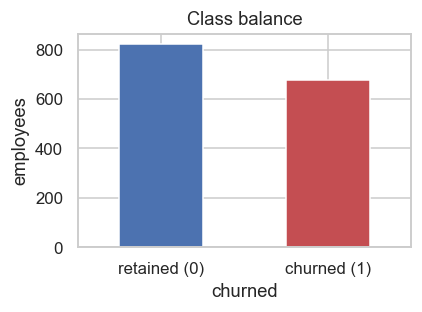

In [3]:
summary = df.describe(include='number').T[['mean', 'std', 'min', 'max']]
display(summary.round(2))

fig, ax = plt.subplots(figsize=(4, 3))
df['churned'].value_counts().sort_index().plot.bar(ax=ax, color=['#4c72b0', '#c44e52'])
ax.set_xticklabels(['retained (0)', 'churned (1)'], rotation=0)
ax.set_title('Class balance'); ax.set_ylabel('employees')
plt.tight_layout(); plt.show()

## Churn by department and gender

Breaking churn down by categorical segments reveals only **mild** structural variation.

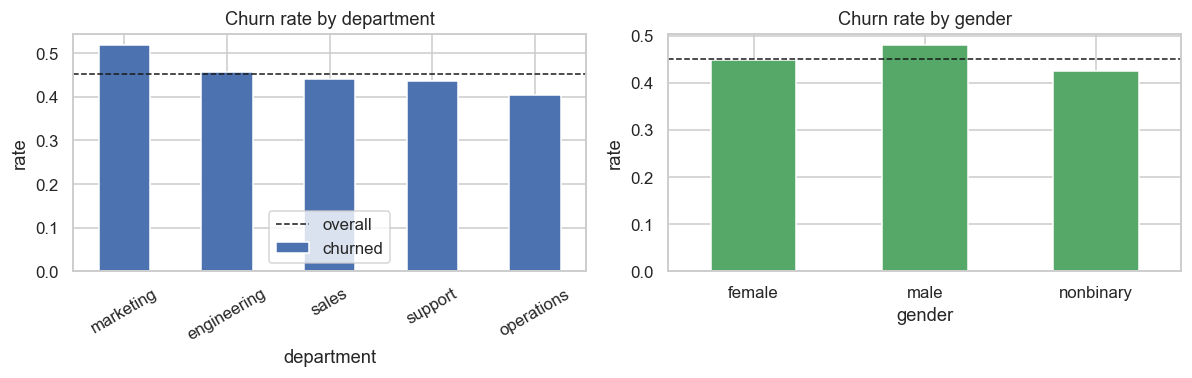

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
(df.groupby('department')['churned'].mean().sort_values(ascending=False)
   .plot.bar(ax=axes[0], color='#4c72b0'))
axes[0].axhline(df['churned'].mean(), ls='--', c='k', lw=1, label='overall')
axes[0].set_title('Churn rate by department'); axes[0].set_ylabel('rate')
axes[0].legend(); axes[0].tick_params(axis='x', rotation=30)
(df.groupby('gender')['churned'].mean()
   .plot.bar(ax=axes[1], color='#55a868'))
axes[1].axhline(df['churned'].mean(), ls='--', c='k', lw=1)
axes[1].set_title('Churn rate by gender'); axes[1].set_ylabel('rate')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

**Reading the charts.** Marketing churns the most (~52%) and operations the least (~40%), but every department sits within ~6 points of the overall 45% line — department alone is a weak predictor. The gender gap is also small in absolute terms (male ~48% vs nonbinary ~43%). Keep that gender spread in mind: it is small here, yet we will see in notebook 04 that the *model* amplifies it into a four-fifths-rule failure.

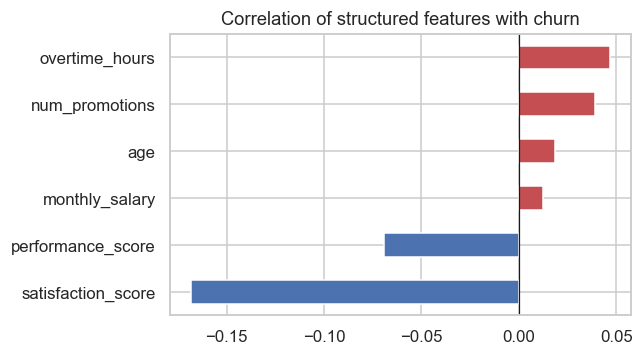

satisfaction_score   -0.168
performance_score    -0.069
monthly_salary        0.012
age                   0.019
num_promotions        0.039
overtime_hours        0.047
dtype: float64

In [5]:
num = df.select_dtypes('number').drop(columns=['employee_id', 'team_id'])
corr = num.corrwith(df['churned']).drop('churned').sort_values()
fig, ax = plt.subplots(figsize=(6, 3.4))
corr.plot.barh(ax=ax, color=np.where(corr < 0, '#4c72b0', '#c44e52'))
ax.set_title('Correlation of structured features with churn')
ax.axvline(0, c='k', lw=0.8)
plt.tight_layout(); plt.show()
corr.round(3)

## Structured features carry a weak signal

The strongest structured correlate of churn is **`satisfaction_score` at only −0.17**, followed by `performance_score` (−0.07). Compensation, age, and overtime are essentially flat (|r| < 0.05). No single structured feature is decisive — a linear model on structured data alone would struggle. This is the central motivation for mining the feedback text.

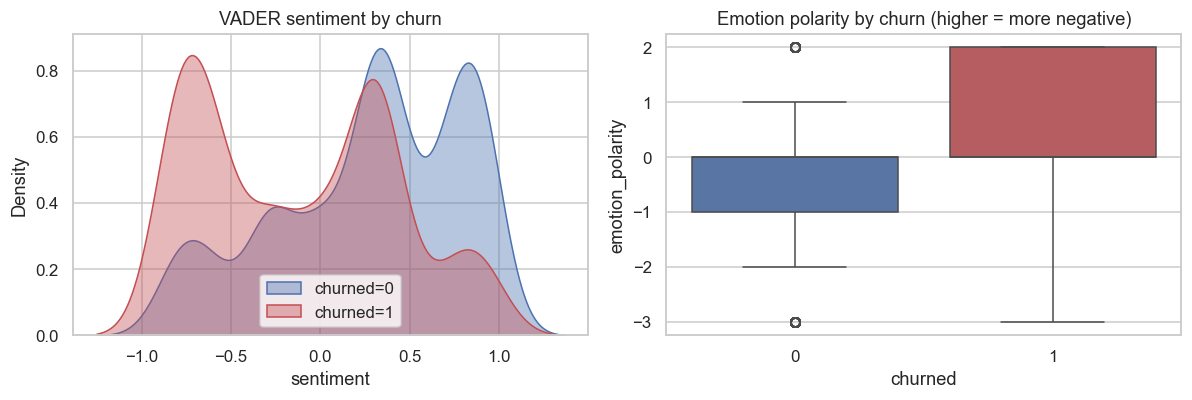

mean sentiment    {0: 0.272, 1: -0.121}
mean emo polarity {0: -0.574, 1: 0.425}


In [6]:
from employee_churn.nlp.sentiment import add_sentiment_scores
from employee_churn.nlp.emotion import add_emotion_features
t = add_sentiment_scores(df, 'feedback')
t = add_emotion_features(t, 'feedback')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for label, color in [(0, '#4c72b0'), (1, '#c44e52')]:
    sns.kdeplot(t.loc[t['churned'] == label, 'sentiment'], ax=axes[0],
                fill=True, alpha=0.4, color=color, label=f'churned={label}')
axes[0].set_title('VADER sentiment by churn'); axes[0].legend()
sns.boxplot(data=t, x='churned', y='emotion_polarity', ax=axes[1],
            palette=['#4c72b0', '#c44e52'])
axes[1].set_title('Emotion polarity by churn (higher = more negative)')
plt.tight_layout(); plt.show()

print('mean sentiment   ', t.groupby('churned')['sentiment'].mean().round(3).to_dict())
print('mean emo polarity', t.groupby('churned')['emotion_polarity'].mean().round(3).to_dict())

## The text tells the story

Now the signal is obvious. **Retained employees average a clearly positive sentiment (~+0.27) while churners average negative (~−0.12)** — the two distributions visibly separate. The lexicon-based `emotion_polarity` (negative-emotion hits minus positive ones) flips sign across the two groups: churners skew positive (more fear/anger/sadness words), retained employees skew negative (more joy/trust words).

Even with the lightweight VADER + lexicon approach, the feedback text separates the classes far better than any structured column. That is the thesis the modeling notebook will confirm quantitatively.

## Takeaways

1. The target is ~balanced (45% churn) — use AUC/F1/precision@k, not accuracy.
2. Structured features are individually weak (best |r| ≈ 0.17, satisfaction).
3. **Text-derived sentiment and emotion are the strongest separators** — the modeling notebook should weight them heavily.
4. A small raw gender gap exists; we must audit whether the model amplifies it (notebook 04).